**Output variables:**


1. Slight-Right-Turn
2. Sharp-Right-Turn
3. Move-Forward
4. Slight-Left-Turn



Uploading and understanding the dataset

In [32]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/ai_project/data/sensor_readings_24.data"
df = pd.read_csv(DATA_PATH, header=None)
X = df.iloc[:, :24].values       # first 24 columns = features
y = df.iloc[:, 24].values                 # the target column

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
unique_values = df[24].unique()
print(unique_values)
value_counts = df[24].value_counts()
print(value_counts)
df.describe()

['Slight-Right-Turn' 'Sharp-Right-Turn' 'Move-Forward' 'Slight-Left-Turn']
24
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


Getting baseline, using majority class and random prediction results

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

import pandas as pd

y_train_series = pd.Series(y_train)
majority_class = y_train_series.value_counts().idxmax()


# Predict majority class for all test samples
y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

# Evaluate
accuracy = accuracy_score(y_test, y_pred_baseline)
macro_f1 = f1_score(y_test, y_pred_baseline, average='macro')
cm = confusion_matrix(y_test, y_pred_baseline)

print("Majority Class Baseline")
print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Confusion Matrix:\n", cm)


Majority Class Baseline
Accuracy: 0.4039589442815249
Macro F1: 0.14386422976501306
Confusion Matrix:
 [[551   0   0   0]
 [524   0   0   0]
 [ 82   0   0   0]
 [207   0   0   0]]


In [37]:
import pandas as pd

y_train_series = pd.Series(y_train)
class_probs = y_train_series.value_counts(normalize=True)

# Random predictions based on class distribution
y_pred_random = np.random.choice(class_probs.index, size=len(y_test), p=class_probs.values)

# Evaluate
accuracy_rand = accuracy_score(y_test, y_pred_random)
macro_f1_rand = f1_score(y_test, y_pred_random, average='macro')

print("Random Predictor Baseline")
print("Accuracy:", accuracy_rand)
print("Macro F1:", macro_f1_rand)



Random Predictor Baseline
Accuracy: 0.34824046920821117
Macro F1: 0.249692488372794


#Logistic regression

In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# -------------------------------
# 1️⃣ Load dataset
# -------------------------------
X = df.iloc[:, :24].values       # first 24 columns = features
y = df.iloc[:, 24].values        # 25th column = target (strings)

# Convert string labels to integers
le = LabelEncoder()
y_int = le.fit_transform(y)

print("Integer labels:", y_int[:10])
print("Classes mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

# -------------------------------
# 2️⃣ Time-based train-test split
# -------------------------------
split_idx = int(0.75 * X.shape[0])  # first 75% = train, last 25% = test

X_train = X[:split_idx]
X_test = X[split_idx:]
y_train_int = y_int[:split_idx]
y_test_int = y_int[split_idx:]

# Add bias term (column of 1s)
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

num_samples, num_features = X_train.shape
num_classes = len(np.unique(y_int))

# One-hot encode the training target
Y_train_onehot = np.zeros((y_train_int.shape[0], num_classes))
for i in range(y_train_int.shape[0]):
    Y_train_onehot[i, y_train_int[i]] = 1

# -------------------------------
# 3️⃣ Define functions
# -------------------------------
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_log_likelihood(X, Y, theta):
    Z = X @ theta
    P = softmax(Z)
    return np.sum(Y * np.log(P + 1e-15))

def train_multinomial_logistic_regression(X, Y, lr=0.1, iterations=2000):
    num_samples, num_features = X.shape
    num_classes = Y.shape[1]

    theta = np.zeros((num_features, num_classes))
    ll_history = []
    for i in range(iterations):
        Z = X @ theta
        P = softmax(Z)
        gradient = X.T @ (Y - P) / num_samples
        theta += lr * gradient

        if i % 100 == 0:  # less frequent printing
            ll = compute_log_likelihood(X, Y, theta)
            print(f"Iteration {i}: Log-likelihood = {ll:.4f}")
            ll_history.append(ll)
    return theta,ll_history

# -------------------------------
# 4️⃣ Train model
# -------------------------------
theta_opt,ll_history = train_multinomial_logistic_regression(
    X_train, Y_train_onehot, lr=0.1, iterations=100000
)

# -------------------------------
# 5️⃣ Predictions on test set
# -------------------------------
Z_test = X_test @ theta_opt
P_test = softmax(Z_test)
y_test_pred = np.argmax(P_test, axis=1)

# -------------------------------
# 6️⃣ Evaluate
# -------------------------------
accuracy = accuracy_score(y_test_int, y_test_pred)
macro_f1 = f1_score(y_test_int, y_test_pred, average='macro')
cm = confusion_matrix(y_test_int, y_test_pred)

print("\nTime-based Test Set Results (24-sensor dataset):")
print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Confusion Matrix:\n", cm)


Integer labels: [3 3 3 3 3 3 3 3 1 1]
Classes mapping: {'Move-Forward': 0, 'Sharp-Right-Turn': 1, 'Slight-Left-Turn': 2, 'Slight-Right-Turn': 3}
Iteration 0: Log-likelihood = -5463.4484
Iteration 100: Log-likelihood = -4499.9070
Iteration 200: Log-likelihood = -4309.1267
Iteration 300: Log-likelihood = -4234.1092
Iteration 400: Log-likelihood = -4190.3474
Iteration 500: Log-likelihood = -4160.9489
Iteration 600: Log-likelihood = -4139.3765
Iteration 700: Log-likelihood = -4122.4998
Iteration 800: Log-likelihood = -4108.6390
Iteration 900: Log-likelihood = -4096.8256
Iteration 1000: Log-likelihood = -4086.4707
Iteration 1100: Log-likelihood = -4077.2006
Iteration 1200: Log-likelihood = -4068.7686
Iteration 1300: Log-likelihood = -4061.0060
Iteration 1400: Log-likelihood = -4053.7933
Iteration 1500: Log-likelihood = -4047.0429
Iteration 1600: Log-likelihood = -4040.6891
Iteration 1700: Log-likelihood = -4034.6808
Iteration 1800: Log-likelihood = -4028.9776
Iteration 1900: Log-likelihood 

**Plots for logistic regression**


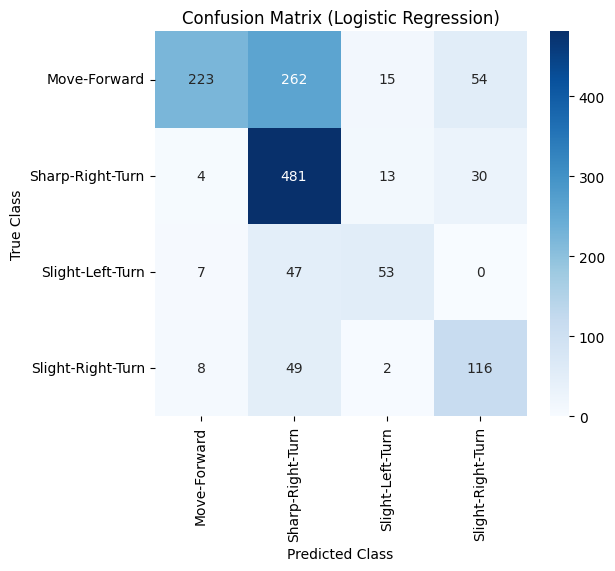

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

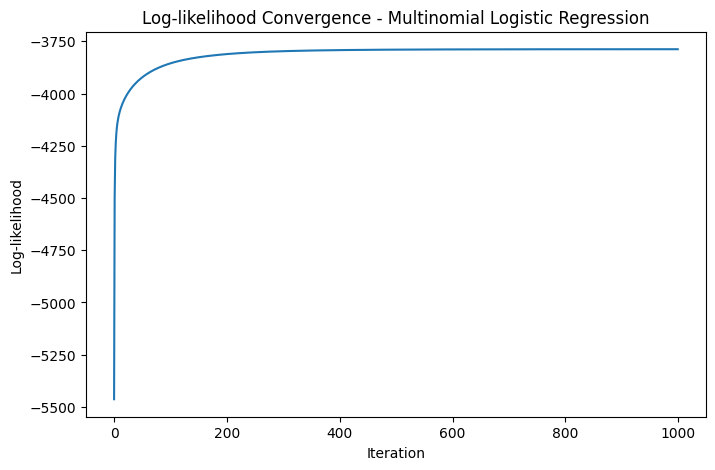

In [46]:
plt.figure(figsize=(8,5))
plt.plot(ll_history)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood Convergence - Multinomial Logistic Regression")
plt.show()

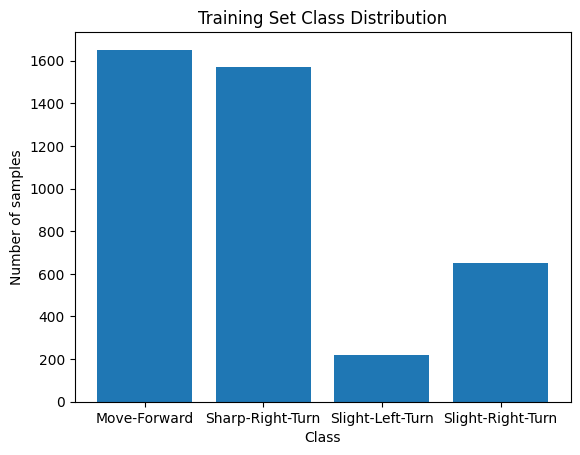

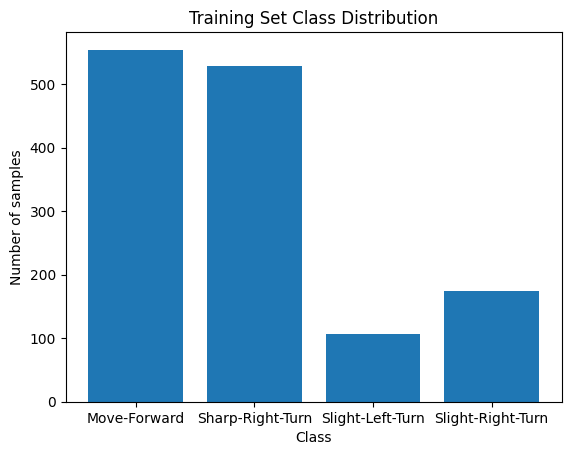

In [49]:
import numpy as np

classes, counts = np.unique(y_train_int, return_counts=True)
plt.bar(classes, counts)
plt.xticks(classes, le.classes_)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Training Set Class Distribution")
plt.show()

classes_test, counts_test = np.unique(y_test_int, return_counts=True)
plt.bar(classes_test, counts_test)
plt.xticks(classes_test, le.classes_)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Training Set Class Distribution")
plt.show()

# Decision Tree

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ Train Decision Tree
# -------------------------------
# Re-create train/test WITHOUT bias
X_train_dt = X_train[:, 1:]   # drop bias column
X_test_dt  = X_test[:, 1:]

dt = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
dt.fit(X_train_dt, y_train_int)

# -------------------------------
# 2️⃣ Predictions on test set
# -------------------------------
y_test_pred_dt = dt.predict(X_test_dt)

# -------------------------------
# 3️⃣ Evaluate
# -------------------------------
accuracy_dt = accuracy_score(y_test_int, y_test_pred_dt)
macro_f1_dt = f1_score(y_test_int, y_test_pred_dt, average='macro')
cm_dt = confusion_matrix(y_test_int, y_test_pred_dt)

print("\nDecision Tree Test Set Results:")
print("Maximum depth of the decision tree:", dt.get_depth())
print("Number of nodes in the decision tree:", dt.tree_.node_count)
print("Accuracy:", accuracy_dt)
print("Macro F1:", macro_f1_dt)
print("Confusion Matrix:\n", cm_dt)



Decision Tree Test Set Results:
Maximum depth of the decision tree: 11
Number of nodes in the decision tree: 73
Accuracy: 0.9860703812316716
Macro F1: 0.9802796981131826
Confusion Matrix:
 [[544   5   2   3]
 [  0 527   1   0]
 [  6   0 101   0]
 [  1   1   0 173]]


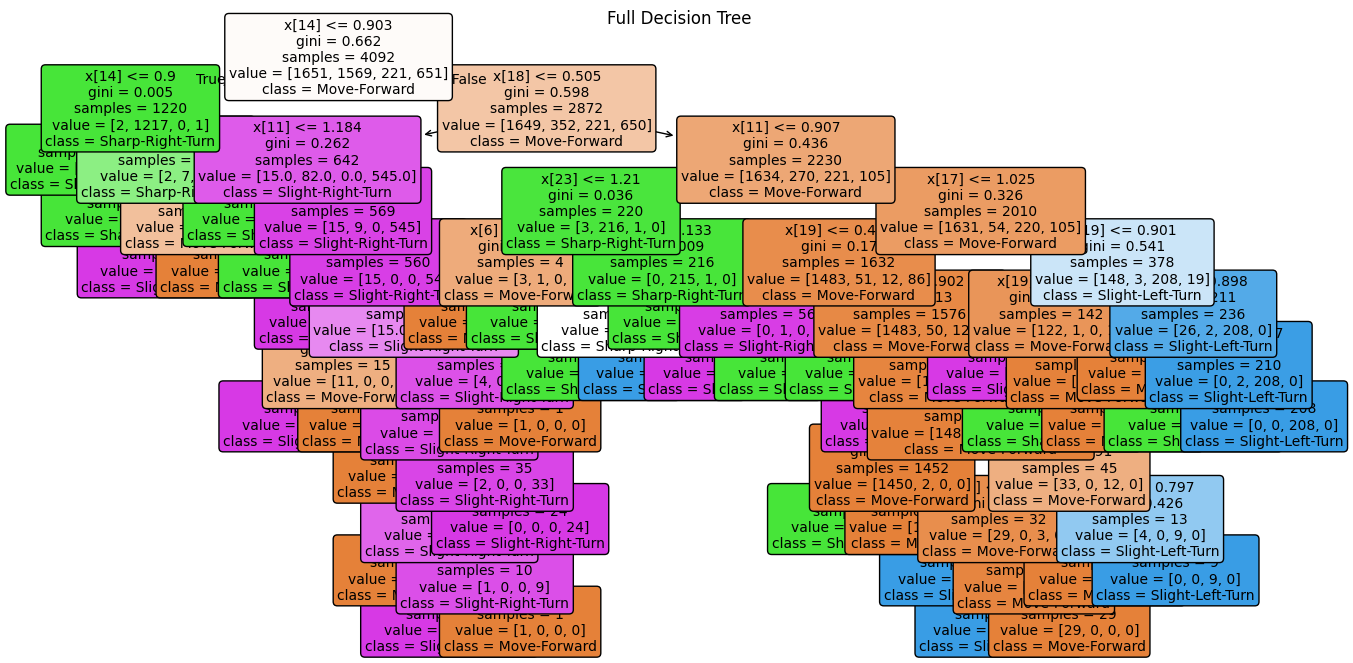

|--- feature_14 <= 0.90
|   |--- feature_14 <= 0.90
|   |   |--- class: 1
|   |--- feature_14 >  0.90
|   |   |--- feature_18 <= 0.71
|   |   |   |--- class: 1
|   |   |--- feature_18 >  0.71
|   |   |   |--- feature_4 <= 1.42
|   |   |   |   |--- class: 3
|   |   |   |--- feature_4 >  1.42
|   |   |   |   |--- class: 0
|--- feature_14 >  0.90
|   |--- feature_18 <= 0.50
|   |   |--- feature_11 <= 1.18
|   |   |   |--- class: 1
|   |   |--- feature_11 >  1.18
|   |   |   |--- feature_13 <= 1.08
|   |   |   |   |--- class: 1
|   |   |   |--- feature_13 >  1.08
|   |   |   |   |--- feature_18 <= 0.50
|   |   |   |   |   |--- class: 3
|   |   |   |   |--- feature_18 >  0.50
|   |   |   |   |   |--- feature_11 <= 1.58
|   |   |   |   |   |   |--- feature_19 <= 0.49
|   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |--- feature_19 >  0.49
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_11 >  1.58
|   |   |   |   |   |   |--- feature_17 <= 2.59
|   

In [65]:
plt.figure(figsize=(16,8))
tree.plot_tree(
    dt,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Full Decision Tree")
plt.show()

tree_rules = tree.export_text(dt)
print(tree_rules)

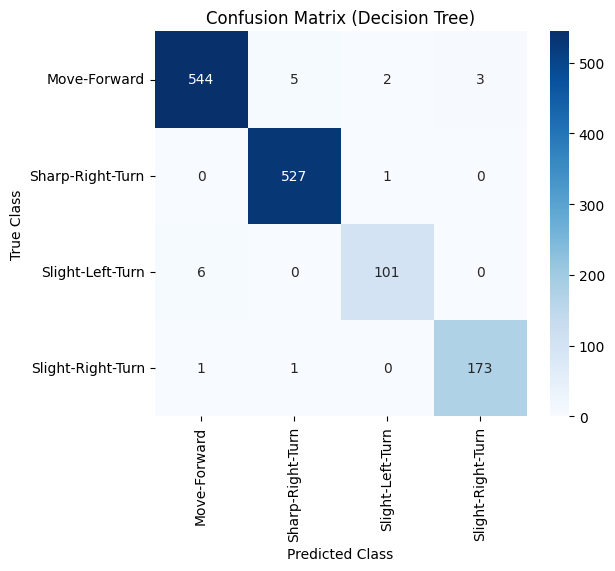

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

# Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# -------------------------------
# 1️⃣ Train Random Forest
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=100,     # number of trees
    criterion='gini',
    max_depth=None,       # grow trees fully
    random_state=42,
    n_jobs=-1             # use all CPU cores
)
# Re-create train/test WITHOUT bias
X_train_rf = X_train[:, 1:]   # drop bias column
X_test_rf  = X_test[:, 1:]

rf.fit(X_train_rf, y_train_int)
importances = rf.feature_importances_



# -------------------------------
# 2️⃣ Predictions on test set
# -------------------------------
y_test_pred_rf = rf.predict(X_test_rf)

# -------------------------------
# 3️⃣ Evaluate
# -------------------------------
accuracy_rf = accuracy_score(y_test_int, y_test_pred_rf)
macro_f1_rf = f1_score(y_test_int, y_test_pred_rf, average='macro')
cm_rf = confusion_matrix(y_test_int, y_test_pred_rf)

print("\nRandom Forest Test Set Results:")
print("Accuracy:", accuracy_rf)
print("Macro F1:", macro_f1_rf)
print("Confusion Matrix:\n", cm_rf)



Random Forest Test Set Results:
Accuracy: 0.9912023460410557
Macro F1: 0.9901684252171329
Confusion Matrix:
 [[545   6   0   3]
 [  0 528   0   0]
 [  1   2 104   0]
 [  0   0   0 175]]


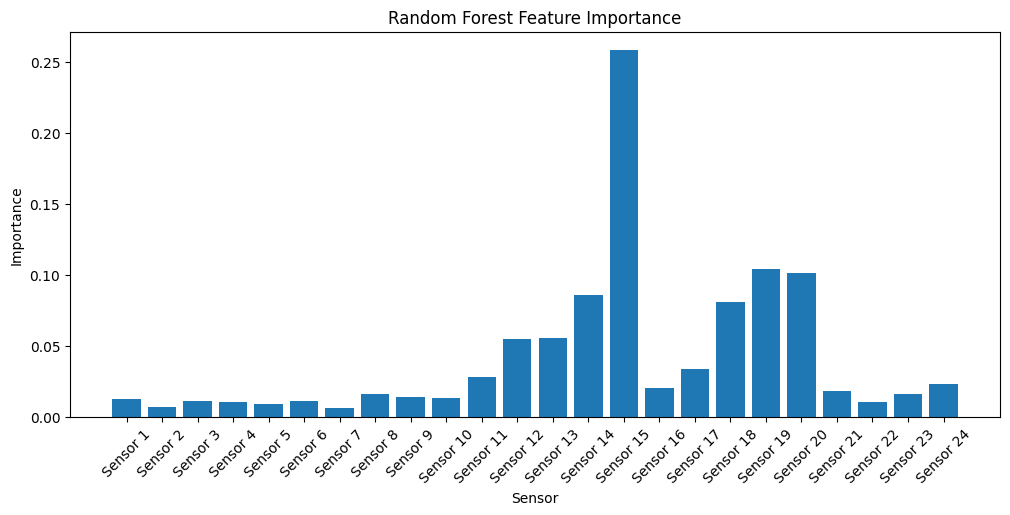

In [68]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
plt.figure(figsize=(12,5))
plt.bar(range(1, 25), importances)
plt.xticks(range(1, 25), [f"Sensor {i+1}" for i in range(24)], rotation=45)
plt.xlabel("Sensor")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()


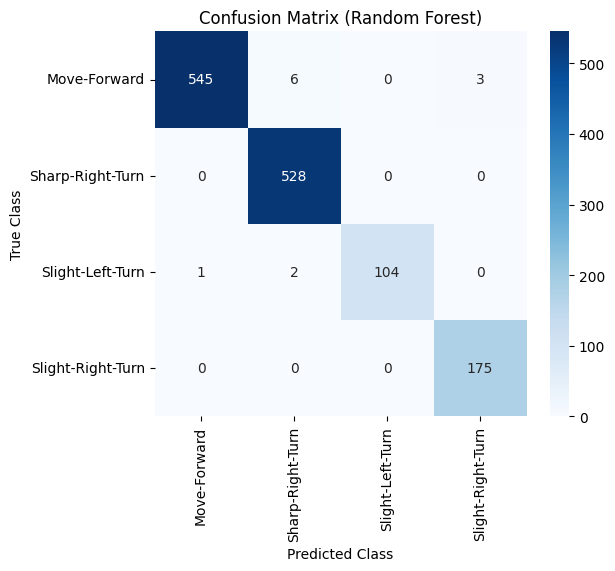

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

# Neural Networks(MLP)

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# -------------------------------
# Train-test split (FIXED)
# -------------------------------
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X, y_int, test_size=0.25, random_state=42, stratify=y_int
)

# -------------------------------
# Scaling (REQUIRED for NN)
# -------------------------------
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn  = scaler.transform(X_test)

# -------------------------------
# Neural Network
# -------------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=4000,
    random_state=42
)

mlp.fit(X_train_nn, y_train_int)

# -------------------------------
# Evaluation
# -------------------------------
y_test_pred_mlp = mlp.predict(X_test_nn)

accuracy_mlp = accuracy_score(y_test_int, y_test_pred_mlp)
macro_f1_mlp = f1_score(y_test_int, y_test_pred_mlp, average='macro')
cm_mlp = confusion_matrix(y_test_int, y_test_pred_mlp)

print("\nNeural Network (MLP) Test Set Results:")
print("Accuracy:", accuracy_mlp)
print("Macro F1:", macro_f1_mlp)
print("Confusion Matrix:\n", cm_mlp)




Neural Network (MLP) Test Set Results:
Accuracy: 0.9384164222873901
Macro F1: 0.9252103769636314
Confusion Matrix:
 [[512  21   5  13]
 [ 15 504   3   2]
 [  6   4  72   0]
 [ 14   0   1 192]]


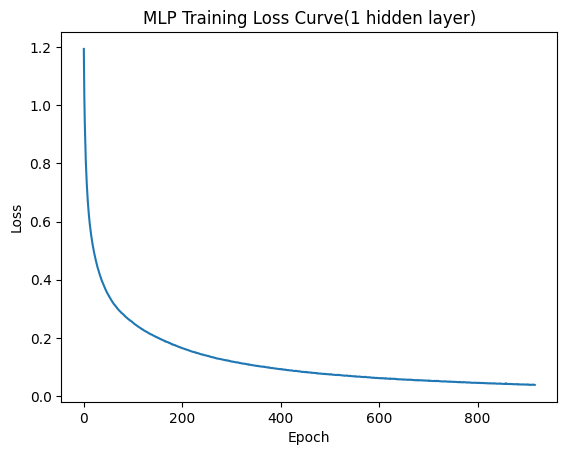

In [81]:
plt.plot(mlp.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve(1 hidden layer)")
plt.show()


In [87]:
# -------------------------------
# Train-test split (FIXED)
# -------------------------------
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X, y_int, test_size=0.25, random_state=42, stratify=y_int
)

# -------------------------------
# Scaling (REQUIRED for NN)
# -------------------------------
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn  = scaler.transform(X_test)

# -------------------------------
# Neural Network
# -------------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=4000,
    random_state=42
)

mlp.fit(X_train_nn, y_train_int)

# -------------------------------
# Evaluation
# -------------------------------
y_test_pred_mlp = mlp.predict(X_test_nn)

accuracy_mlp = accuracy_score(y_test_int, y_test_pred_mlp)
macro_f1_mlp = f1_score(y_test_int, y_test_pred_mlp, average='macro')
cm_mlp = confusion_matrix(y_test_int, y_test_pred_mlp)

print("\nNeural Network (MLP) Test Set Results:")
print("Accuracy:", accuracy_mlp)
print("Macro F1:", macro_f1_mlp)
print("Confusion Matrix:\n", cm_mlp)



Neural Network (MLP) Test Set Results:
Accuracy: 0.9384164222873901
Macro F1: 0.9252103769636314
Confusion Matrix:
 [[512  21   5  13]
 [ 15 504   3   2]
 [  6   4  72   0]
 [ 14   0   1 192]]


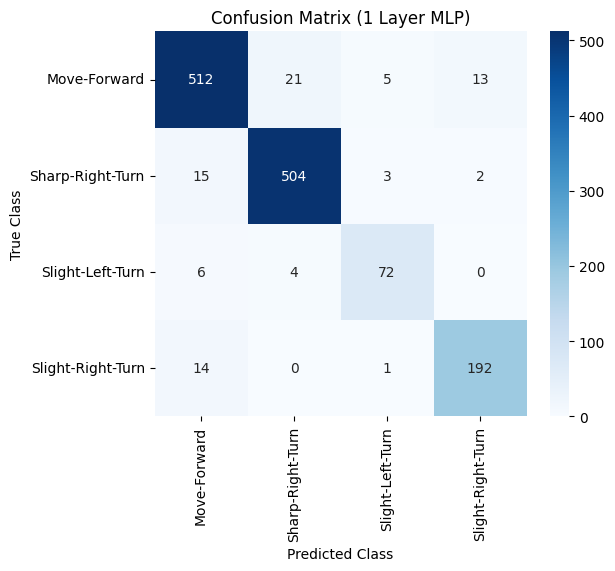

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (1 Layer MLP)")
plt.show()

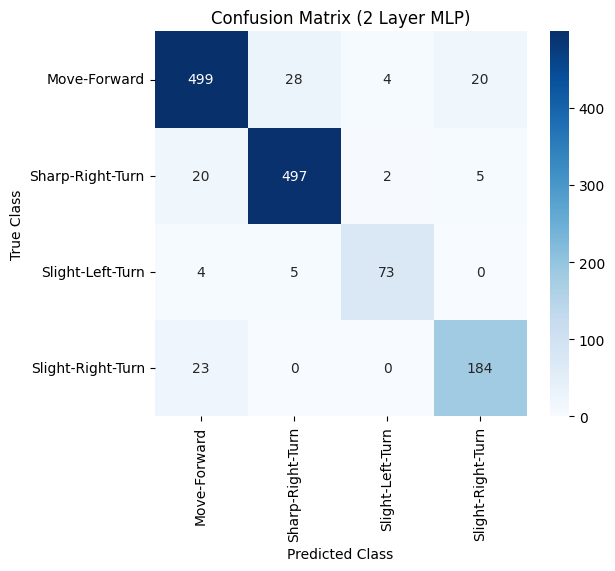

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (2 Layer MLP)")
plt.show()

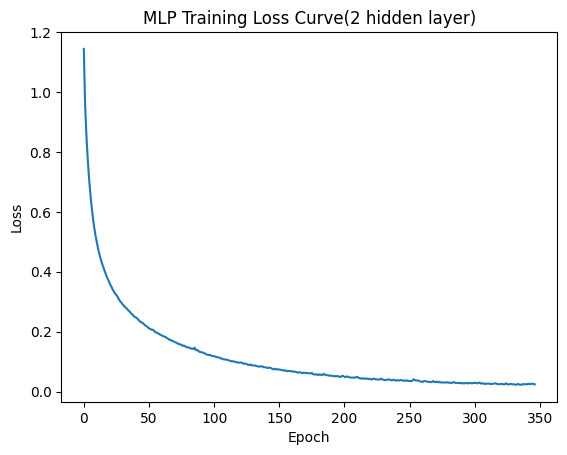

In [85]:
plt.plot(mlp.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve(2 hidden layer)")
plt.show()

# Final Comparisons

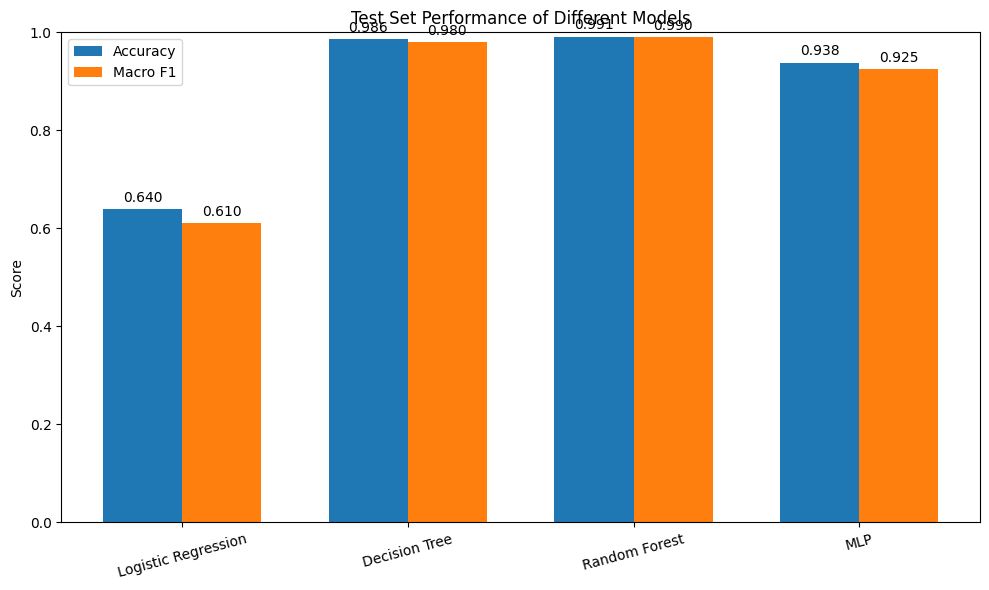

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["Logistic Regression", "Decision Tree", "Random Forest", "MLP"]

# Corresponding metrics from your experiments
accuracy_scores = [accuracy, accuracy_dt, accuracy_rf, accuracy_mlp]
macro_f1_scores = [macro_f1, macro_f1_dt, macro_f1_rf, macro_f1_mlp]

x = np.arange(len(models))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy')
rects2 = ax.bar(x + width/2, macro_f1_scores, width, label='Macro F1')

# Labels
ax.set_ylabel('Score')
ax.set_title('Test Set Performance of Different Models')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0,1)
ax.legend()

# Annotate bars with values
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()
